In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings("ignore")
import joblib
import os

### Load and Examine the Dataset

In [2]:
df = pd.read_csv("C:\\Users\\HP\\Desktop\\Ai project\\reels_attention_span_dataset_12000.csv")
df

,user_id,age,reels_watch_time_hours,daily_screen_time_hours,sleep_hours,attention_span_score,focus_level,task_completion_rate,stress_level,platform
0,1,21,1.86,7.34,8.95,4.99,5.09,45.44,Medium,TikTok
1,2,34,3.03,5.78,5.78,3.73,8.25,50.17,High,TikTok
2,3,43,3.96,9.62,5.46,5.48,8.96,43.27,Low,TikTok
3,4,29,3.56,7.25,5.09,5.54,9.77,64.99,Low,Instagram Reels
4,5,25,4.58,2.13,8.12,8.07,4.11,89.28,Low,Instagram Reels
...,...,...,...,...,...,...,...,...,...,...
11995,11996,27,4.14,6.29,7.71,4.96,3.00,97.38,High,TikTok
11996,11997,42,4.07,3.27,4.20,1.02,3.30,40.79,High,Instagram Reels
11997,11998,25,0.82,3.19,6.16,7.59,1.30,41.71,Low,Instagram Reels
11998,11999,39,1.70,3.65,7.15,8.90,1.92,71.05,High,TikTok


In [3]:
df.tail()

,user_id,age,reels_watch_time_hours,daily_screen_time_hours,sleep_hours,attention_span_score,focus_level,task_completion_rate,stress_level,platform
11995,11996,27,4.14,6.29,7.71,4.96,3.00,97.38,High,TikTok
11996,11997,42,4.07,3.27,4.20,1.02,3.30,40.79,High,Instagram Reels
11997,11998,25,0.82,3.19,6.16,7.59,1.30,41.71,Low,Instagram Reels
11998,11999,39,1.70,3.65,7.15,8.90,1.92,71.05,High,TikTok
11999,12000,33,5.79,10.91,4.35,5.36,3.65,91.36,High,TikTok


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   user_id                  12000 non-null  int64  
 1   age                      12000 non-null  int64  
 2   reels_watch_time_hours   12000 non-null  float64
 3   daily_screen_time_hours  12000 non-null  float64
 4   sleep_hours              12000 non-null  float64
 5   attention_span_score     12000 non-null  float64
 6   focus_level              12000 non-null  float64
 7   task_completion_rate     12000 non-null  float64
 8   stress_level             12000 non-null  object 
 9   platform                 12000 non-null  object 
dtypes: float64(6), int64(2), object(2)
memory usage: 937.6+ KB


### Handle Missing Values

In [5]:
df.isna().sum()

user_id                    0
age                        0
reels_watch_time_hours     0
daily_screen_time_hours    0
sleep_hours                0
attention_span_score       0
focus_level                0
task_completion_rate       0
stress_level               0
platform                   0
dtype: int64

### Handle Dublicated Values

In [6]:
df.duplicated().sum()

np.int64(0)

### Drop Irrelevent Coloums and Objects

In [7]:
df = df.drop(columns=['user_id'])

In [8]:
rd = df.select_dtypes(include=['object']).columns
le = LabelEncoder()
for col in rd:
    df[col] = le.fit_transform(df[col])
df.head()

,age,reels_watch_time_hours,daily_screen_time_hours,sleep_hours,attention_span_score,focus_level,task_completion_rate,stress_level,platform
0,21,1.86,7.34,8.95,4.99,5.09,45.44,2,1
1,34,3.03,5.78,5.78,3.73,8.25,50.17,0,1
2,43,3.96,9.62,5.46,5.48,8.96,43.27,1,1
3,29,3.56,7.25,5.09,5.54,9.77,64.99,1,0
4,25,4.58,2.13,8.12,8.07,4.11,89.28,1,0


### Normalize Numbers

In [9]:
x = df.drop("attention_span_score", axis=1)
y = df["attention_span_score"]
scaler = MinMaxScaler()
x_scaled = pd.DataFrame(scaler.fit_transform(x), columns=x.columns)
x_scaled.describe().round(3)

,age,reels_watch_time_hours,daily_screen_time_hours,sleep_hours,focus_level,task_completion_rate,stress_level,platform
count,12000.000,12000.000,12000.000,12000.000,12000.000,12000.000,12000.000,12000.000
mean,0.506,0.499,0.502,0.499,0.501,0.502,0.499,0.498
std,0.298,0.288,0.287,0.289,0.288,0.287,0.409,0.408
min,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,0.241,0.251,0.256,0.246,0.254,0.253,0.000,0.000
50%,0.517,0.496,0.503,0.500,0.501,0.504,0.500,0.500
75%,0.759,0.749,0.747,0.748,0.753,0.750,1.000,1.000
max,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000


### EDA Report

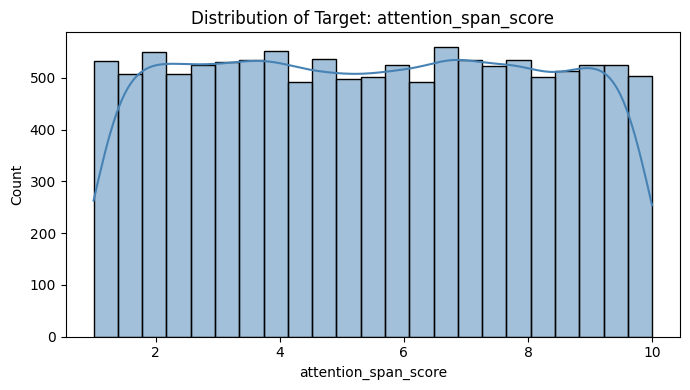

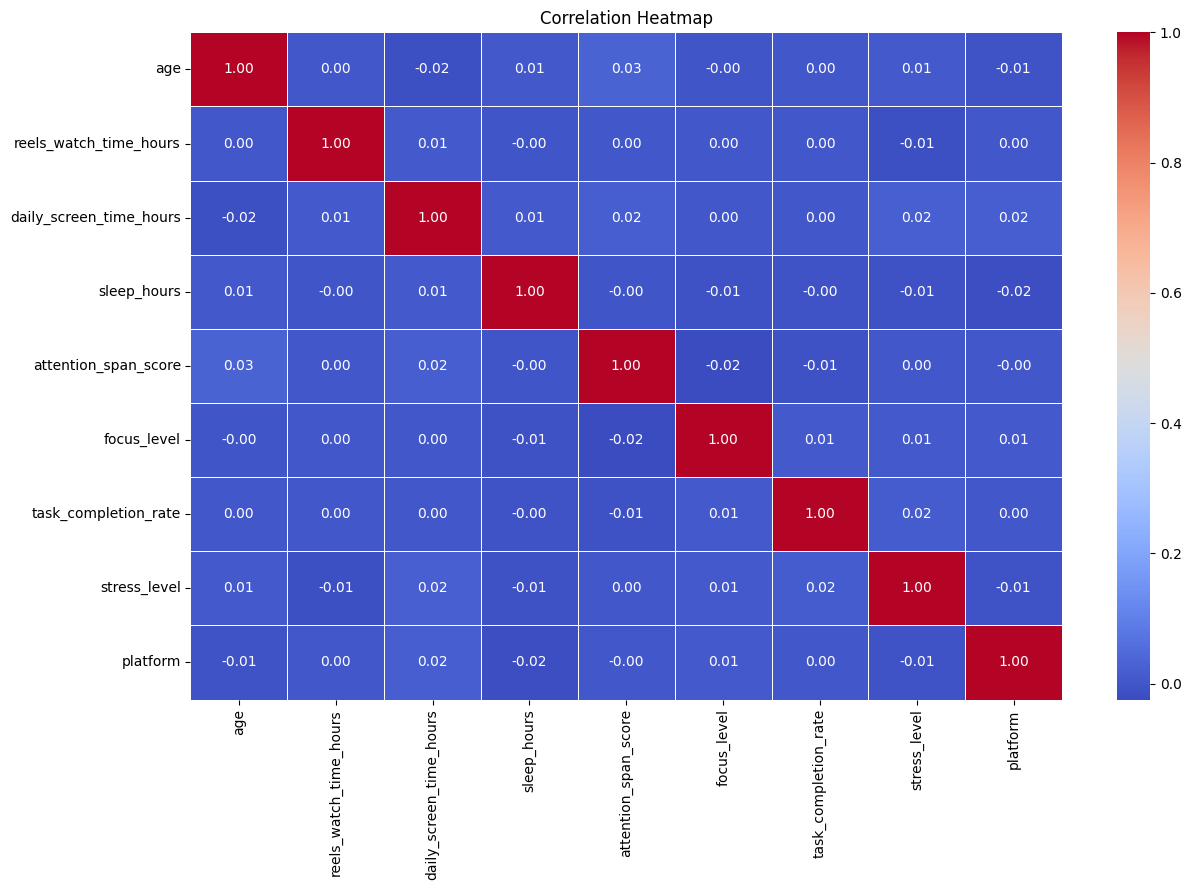

Top correlations with target:
age                        0.027932
focus_level                0.024572
daily_screen_time_hours    0.016300
task_completion_rate       0.010678
stress_level               0.002346
sleep_hours                0.002170
reels_watch_time_hours     0.000760
platform                   0.000425
Name: attention_span_score, dtype: float64


In [10]:
plt.figure(figsize=(7, 4))
sns.histplot(y, kde=True, color='steelblue')
plt.title("Distribution of Target: attention_span_score")
plt.xlabel("attention_span_score")
plt.tight_layout()
plt.show()

plt.figure(figsize=(13, 9))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

print("Top correlations with target:")
print(df.corr()['attention_span_score'].drop('attention_span_score').abs().sort_values(ascending=False).head(10))

### Train/Test Split 

In [11]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [12]:
x

,age,reels_watch_time_hours,daily_screen_time_hours,sleep_hours,focus_level,task_completion_rate,stress_level,platform
0,21,1.86,7.34,8.95,5.09,45.44,2,1
1,34,3.03,5.78,5.78,8.25,50.17,0,1
2,43,3.96,9.62,5.46,8.96,43.27,1,1
3,29,3.56,7.25,5.09,9.77,64.99,1,0
4,25,4.58,2.13,8.12,4.11,89.28,1,0
...,...,...,...,...,...,...,...,...
11995,27,4.14,6.29,7.71,3.00,97.38,0,1
11996,42,4.07,3.27,4.20,3.30,40.79,0,0
11997,25,0.82,3.19,6.16,1.30,41.71,1,0
11998,39,1.70,3.65,7.15,1.92,71.05,0,1


In [13]:
y

0        4.99
1        3.73
2        5.48
3        5.54
4        8.07
         ... 
11995    4.96
11996    1.02
11997    7.59
11998    8.90
11999    5.36
Name: attention_span_score, Length: 12000, dtype: float64

### Linear Regression

In [14]:
lr = LinearRegression()
lr.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [15]:
y_pred = lr.predict(x_test)
print("Predicted values:", y_pred)
print("Actual values:", y_test.values)

Predicted values: [5.45463942 5.31279736 5.63847727 ... 5.56278397 5.4297488  5.35380254]
Actual values: [3.48 2.95 1.76 ... 8.1  2.1  1.46]


In [16]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print("Linear Regression:")
print("  MAE:", mae)
print("  RMSE:", rmse)
print("  R2:", r2)

Linear Regression:
  MAE: 2.263841217844487
  RMSE: 2.601470391565793
  R2: -2.8683751511104916e-05


### Random Forest

In [17]:
rf = RandomForestRegressor()
rf.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [18]:
y_pred_rf = rf.predict(x_test)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)
print("Random Forest Regressor:")
print("  MAE:", mae_rf)
print("  RMSE:", rmse_rf)
print("  R2:", r2_rf)

Random Forest Regressor:
  MAE: 2.3066892083333332
  RMSE: 2.6659252491638186
  R2: -0.05019662457693341


### Hyperparameter Tuning with GridSearchCV

In [19]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=3,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(x_train, y_train)

best_rf = grid_search.best_estimator_
y_pred_best = best_rf.predict(x_test)

mae_best  = mean_absolute_error(y_test, y_pred_best)
rmse_best = np.sqrt(mean_squared_error(y_test, y_pred_best))
r2_best   = r2_score(y_test, y_pred_best)

print("Best Parameters:", grid_search.best_params_)
print("Tuned Random Forest Regressor:")
print("  MAE:", mae_best)
print("  RMSE:", rmse_best)
print("  R2:", r2_best)

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best Parameters: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}
Tuned Random Forest Regressor:
  MAE: 2.274680783940969
  RMSE: 2.6189647731325754
  R2: -0.013523904200187342


### Comparing Results

            Model      MAE     RMSE        R²
Linear Regression 2.263841 2.601470 -0.000029
    Random Forest 2.306689 2.665925 -0.050197
         Tuned RF 2.274681 2.618965 -0.013524


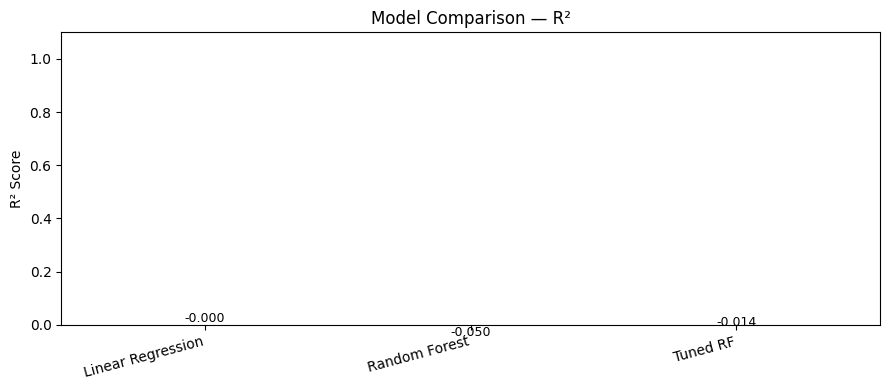

In [20]:
results = pd.DataFrame({
    'Model':  ['Linear Regression', 'Random Forest', 'Tuned RF'],
    'MAE':    [mae,  mae_rf,  mae_best],
    'RMSE':   [rmse, rmse_rf, rmse_best],
    'R²':     [r2,   r2_rf,  r2_best]
})
print(results.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4))
colors = ['#4c78a8', '#f58518', '#e45756', '#72b7b2']
bars = ax.bar(results['Model'], results['R²'], color=colors)
ax.set_ylim(0, 1.1)
ax.set_ylabel("R² Score")
ax.set_title("Model Comparison — R²")
for b in bars:
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.01,
            f"{b.get_height():.3f}", ha='center', fontsize=9)
plt.xticks(rotation=15, ha='right')
plt.tight_layout()

### Predicted VS Acutal Results

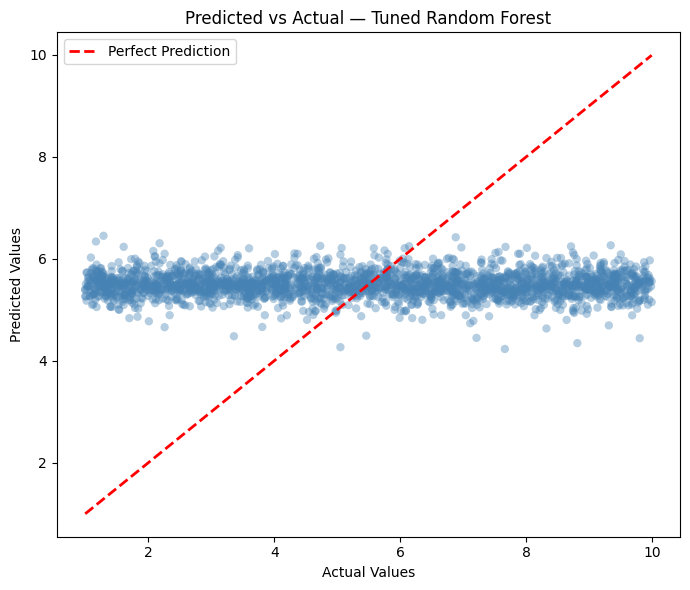

In [21]:
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred_best, alpha=0.4, color='steelblue', edgecolors='none')
mn, mx = float(y_test.min()), float(y_test.max())
plt.plot([mn, mx], [mn, mx], 'r--', linewidth=2, label='Perfect Prediction')
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Predicted vs Actual — Tuned Random Forest")
plt.legend()
plt.tight_layout()

### Feature Distributions Visualization

In [22]:
fig = make_subplots(
    rows=2, cols=3,
    subplot_titles=list(x.columns[:6])
)
for i, col in enumerate(x.columns[:6]):
    r, c = divmod(i, 3)
    fig.add_trace(go.Histogram(x=df[col], name=col, showlegend=False), row=r+1, col=c+1)

fig.update_layout(title_text="Feature Distributions", height=500)
fig.show()
print("Inspect how each feature is distributed - skewed features may affect model performance")

Inspect how each feature is distributed - skewed features may affect model performance


### Feature Importance Visualization

In [23]:
imp_df = pd.DataFrame({
    'Feature': x.columns,
    'Importance': best_rf.feature_importances_
}).sort_values('Importance', ascending=True)

fig = px.bar(imp_df, x='Importance', y='Feature', orientation='h',
             title='Feature Importances — Tuned Random Forest',
             color='Importance', color_continuous_scale='Blues')
fig.update_layout(coloraxis_showscale=False, height=500)
fig.show()
print("Features with the highest importance are the strongest drivers of attention span score")

Features with the highest importance are the strongest drivers of attention span score


### Correlation Heatmap

In [24]:
corr_vals = df.corr().round(2)
fig = px.imshow(
    corr_vals,
    text_auto=True,
    color_continuous_scale='RdBu_r',
    title='Interactive Correlation Heatmap',
    aspect='auto'
)
fig.update_layout(height=600)
fig.show()
print("Strong correlations with the target reveal which variables most influence attention span score")

Strong correlations with the target reveal which variables most influence attention span score


### Model Comparison Visualization

In [25]:
fig = px.bar(
    results.melt(id_vars='Model', value_vars=['MAE', 'RMSE', 'R²'],
                 var_name='Metric', value_name='Score'),
    x='Metric', y='Score', color='Model', barmode='group',
    title='Interactive Model Comparison — All Metrics'
)
fig.update_layout(height=450)
fig.show()
print("Lower MAE/RMSE and higher R² indicate a better model.")

Lower MAE/RMSE and higher R² indicate a better model.


### Save Artifacts

In [26]:
joblib.dump(best_rf, 'attention_span_model.pkl')
joblib.dump(scaler,  'attention_span_scaler.pkl')

['attention_span_scaler.pkl']